# NB6b — Per-Class Breakdown, Confusion Matrices & Error Audit

**GastroNet project — Part D, step 6 (C.2 item 2).** Runs between NB6 (done) and NB7 (explainability) — pure analysis on data already saved, no new training or checkpoints needed.

### Purpose
NB6 established that none of the 4 architectures differ significantly on *overall* accuracy. This notebook asks a different question: **when they do make errors, is it the same errors?** Two very different explanations would produce the same accuracy numbers:
1. All 4 models struggle on the *same specific images/class pairs* — consistent with those images being genuinely ambiguous or borderline ground truth (a real, citable explanation for the accuracy ceiling per A.2/A.3), not an architecture weakness.
2. Each architecture fails on *different* images — consistent with each one having a distinct failure mode that happens to average out to a similar accuracy.

Per the handoff doc, this should run **before NB7**, since whichever images turn out to be hardest/most-agreed-upon-as-wrong are exactly what NB7's Grad-CAM and cross-attention maps should be pointed at.

Uses the same majority-vote ensemble per model family established in NB6 (one clean prediction per test image per model, no seed pseudo-replication).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json, glob, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.metrics import classification_report, confusion_matrix

EXPERIMENTS_ROOT = "/content/drive/MyDrive/gastronet_experiments"
RAW_DATASET_DIR  = "/content/drive/MyDrive/gastronet_raw_dataset"  # only used for the image-grid cell (Section 6)
MODEL_FAMILIES = ["cnn_only_v2", "vit_only_v2", "hybrid_concat_v2", "hybrid_crossattn_v2"]
SEEDS = [42, 123, 7]

## 2. Load results (same robust loader as NB6)

Self-contained — doesn't depend on NB6 having been run first, matching the project's own convention of each notebook only depending on Drive-persisted state, not on other notebooks' in-memory state.

In [3]:
def normalize(name):
    return name.lower().replace("_", "").replace("-", "")

def find_result_file(results_root, family, seed):
    nested = os.path.join(results_root, family, f"seed_{seed}", "results.json")
    if os.path.exists(nested):
        return nested
    flat = os.path.join(results_root, f"{family}_seed{seed}_results.json")
    if os.path.exists(flat):
        return flat
    target = normalize(family)
    for fp in glob.glob(os.path.join(results_root, "**", "*.json"), recursive=True):
        base = os.path.basename(fp)
        seed_matches = [int(x) for x in re.findall(r"seed_?(\d+)", base)]
        if seed in seed_matches and normalize(base).startswith(target[:12]):
            return fp
    return None

def load_all(results_root):
    data = defaultdict(dict)
    missing = []
    for family in MODEL_FAMILIES:
        for seed in SEEDS:
            fp = find_result_file(results_root, family, seed)
            if fp is None:
                missing.append((family, seed))
                continue
            with open(fp) as f:
                data[family][seed] = json.load(f)
    return data, missing

data, missing = load_all(EXPERIMENTS_ROOT)
if missing:
    raise FileNotFoundError(f"Could not locate results.json for: {missing}")

all_results = [data[fam][seed] for fam in MODEL_FAMILIES for seed in SEEDS]
split_hashes = set(r["split_hash"] for r in all_results)
assert len(split_hashes) == 1, f"split_hash MISMATCH: {split_hashes}"
SPLIT_HASH = split_hashes.pop()

label_seqs = set(tuple(r["labels"]) for r in all_results)
assert len(label_seqs) == 1, "label sequences differ across files"
LABELS = np.array(list(label_seqs)[0])
CLASS_NAMES = all_results[0]["class_names"]
print(f"[OK] {len(all_results)} results loaded, split_hash={SPLIT_HASH}, {len(LABELS)} test images, classes={CLASS_NAMES}")

[OK] 12 results loaded, split_hash=d6e80caa29bff18856ae93ea635b4650, 400 test images, classes=['Diverticulosis', 'Neoplasm', 'Peritonitis', 'Ureters']


## 3. Majority-vote ensemble per model family

Same construction as NB6 — one representative prediction per test image per model family, combining its 3 seeds by majority vote.

In [4]:
def majority_vote_ensemble(fam):
    seed_order_by_val = sorted(SEEDS, key=lambda s: -data[fam][s]["best_val_acc"])
    tiebreak_seed = seed_order_by_val[0]
    preds_by_seed = {s: np.array(data[fam][s]["predictions"]) for s in SEEDS}
    n = len(LABELS)
    ensemble = np.zeros(n, dtype=int)
    for i in range(n):
        votes = [preds_by_seed[s][i] for s in SEEDS]
        counts = Counter(votes)
        top_count = max(counts.values())
        winners = [cls for cls, c in counts.items() if c == top_count]
        ensemble[i] = winners[0] if len(winners) == 1 else preds_by_seed[tiebreak_seed][i]
    return ensemble

ensembles = {fam: majority_vote_ensemble(fam) for fam in MODEL_FAMILIES}
for fam in MODEL_FAMILIES:
    print(f"{fam:22s} ensemble_acc={(ensembles[fam]==LABELS).mean():.4f}")

cnn_only_v2            ensemble_acc=0.9825
vit_only_v2            ensemble_acc=0.9850
hybrid_concat_v2       ensemble_acc=0.9750
hybrid_crossattn_v2    ensemble_acc=0.9700


## 4. Per-class precision/recall/F1 and confusion matrices

In [5]:
for fam in MODEL_FAMILIES:
    print(f"\n{'='*60}\n{fam}\n{'='*60}")
    print(classification_report(LABELS, ensembles[fam], target_names=CLASS_NAMES, digits=3))
    print("Confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(confusion_matrix(LABELS, ensembles[fam]), index=CLASS_NAMES, columns=CLASS_NAMES))


cnn_only_v2
                precision    recall  f1-score   support

Diverticulosis      1.000     1.000     1.000       100
      Neoplasm      0.970     0.980     0.975       100
   Peritonitis      0.970     0.980     0.975       100
       Ureters      0.990     0.970     0.980       100

      accuracy                          0.983       400
     macro avg      0.983     0.982     0.983       400
  weighted avg      0.983     0.983     0.983       400

Confusion matrix (rows=true, cols=predicted):
                Diverticulosis  Neoplasm  Peritonitis  Ureters
Diverticulosis             100         0            0        0
Neoplasm                     0        98            1        1
Peritonitis                  0         2           98        0
Ureters                      0         1            2       97

vit_only_v2
                precision    recall  f1-score   support

Diverticulosis      1.000     1.000     1.000       100
      Neoplasm      0.971     0.990     0.980    

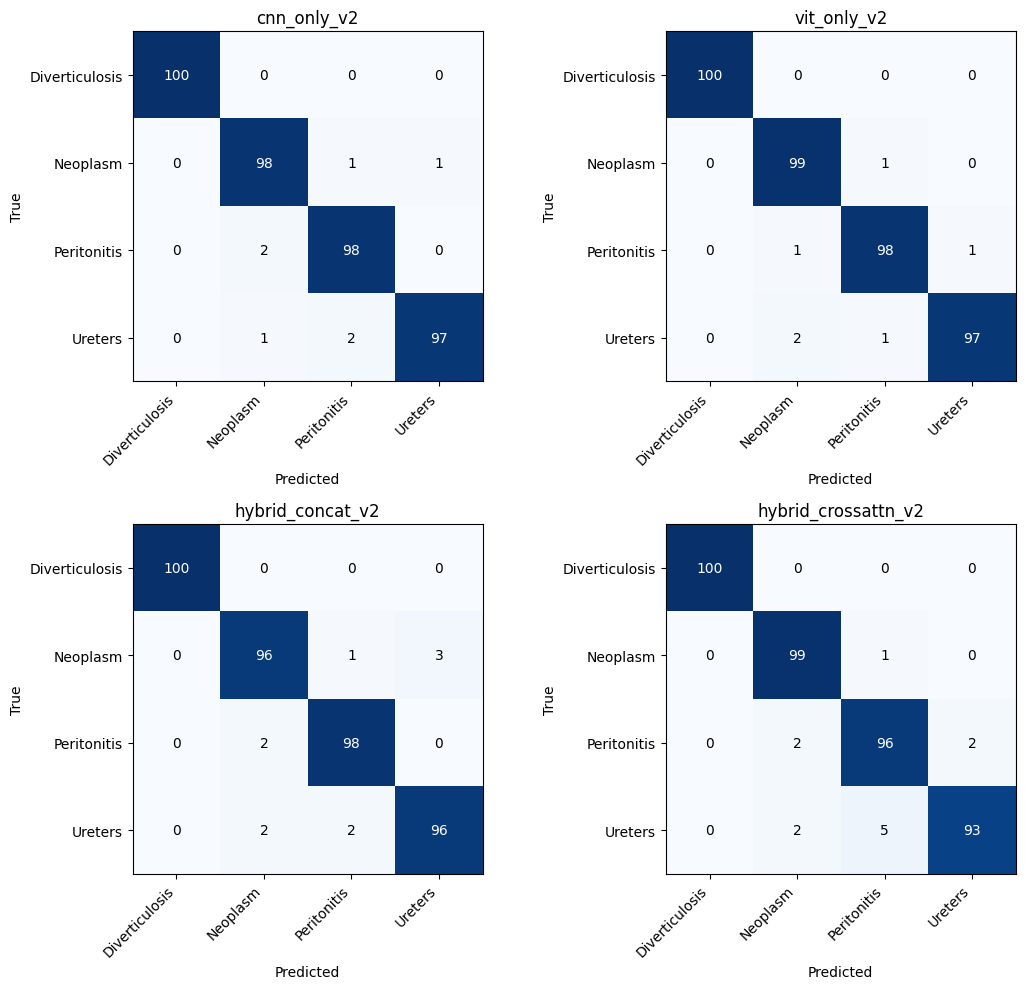

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, fam in zip(axes.flat, MODEL_FAMILIES):
    cm = confusion_matrix(LABELS, ensembles[fam])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(fam)
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENTS_ROOT, "analysis", "nb6b_confusion_matrices.png")) if os.path.isdir(os.path.join(EXPERIMENTS_ROOT, "analysis")) else None
plt.show()

## 5. Cross-model error-pattern analysis

The key question from the intro: do the 4 architectures fail on the *same* images, or *different* ones?

In [7]:
n = len(LABELS)
error_matrix = np.zeros((n, len(MODEL_FAMILIES)), dtype=int)
for j, fam in enumerate(MODEL_FAMILIES):
    error_matrix[:, j] = (ensembles[fam] != LABELS).astype(int)
n_models_wrong = error_matrix.sum(axis=1)

print("Distribution: how many of the 4 models get each test image wrong?")
dist = Counter(n_models_wrong.tolist())
for k in sorted(dist):
    label = "all models correct" if k == 0 else ("ALL 4 models wrong" if k == 4 else f"{k} model(s) wrong")
    print(f"  {k}: {dist[k]:3d} images  ({label})")

pair_counter = Counter()
for fam in MODEL_FAMILIES:
    wrong_idx = np.where(ensembles[fam] != LABELS)[0]
    for i in wrong_idx:
        pair_counter[(CLASS_NAMES[LABELS[i]], CLASS_NAMES[ensembles[fam][i]])] += 1

print("\nMost common (true -> predicted) confusion pairs, pooled across all 4 models:")
pair_df = pd.DataFrame(
    [(t, p, c) for (t, p), c in pair_counter.most_common()],
    columns=["true_class", "predicted_as", "count_across_all_models"]
)
print(pair_df.to_string(index=False))

Distribution: how many of the 4 models get each test image wrong?
  0: 381 images  (all models correct)
  1:  11 images  (1 model(s) wrong)
  2:   3 images  (2 model(s) wrong)
  3:   2 images  (3 model(s) wrong)
  4:   3 images  (ALL 4 models wrong)

Most common (true -> predicted) confusion pairs, pooled across all 4 models:
 true_class predicted_as  count_across_all_models
    Ureters  Peritonitis                       10
Peritonitis     Neoplasm                        7
    Ureters     Neoplasm                        7
   Neoplasm  Peritonitis                        4
   Neoplasm      Ureters                        4
Peritonitis      Ureters                        3


## 6. Error registry — resolve each error back to its actual image

`results.json` only stores integer `predictions`/`labels`, not file paths. But the test loader in every training notebook is built with `shuffle=False` over `dataset_split_v2.json`'s `split["test"]` list, so `predictions[i]` / `labels[i]` corresponds exactly to `split["test"][i]` — this cell loads that list fresh and joins it against the error data by index, then double-checks the join actually lines up (labels from the split match `LABELS` from the results) before trusting anything downstream.

In [8]:
SPLIT_JSON_PATH = os.path.join(EXPERIMENTS_ROOT, "dataset_split_v2.json")
with open(SPLIT_JSON_PATH) as f:
    split_payload = json.load(f)
assert split_payload["split_hash"] == SPLIT_HASH, "dataset_split_v2.json doesn't match the split_hash in your results.json files!"
test_entries = split_payload["split"]["test"]  # list of [path, class_name], in order
assert len(test_entries) == len(LABELS), f"split has {len(test_entries)} test entries, results have {len(LABELS)}"

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
split_labels_as_idx = np.array([class_to_idx[cls] for _, cls in test_entries])
assert np.array_equal(split_labels_as_idx, LABELS), (
    "Index alignment check FAILED: dataset_split_v2.json's test-set class order "
    "doesn't match results.json's labels order. Do not trust the image paths below "
    "until this is resolved (likely means a different split version, or the test "
    "loader was not built with shuffle=False)."
)
print("[OK] Index alignment confirmed -- test_entries[i] really is the image behind predictions[i]/labels[i].")

rows = []
for i in range(n):
    if n_models_wrong[i] == 0:
        continue
    row = {
        "test_index": i,
        "image_path": test_entries[i][0],
        "true_class": CLASS_NAMES[LABELS[i]],
        "n_models_wrong": int(n_models_wrong[i]),
    }
    for fam in MODEL_FAMILIES:
        row[f"{fam}_pred"] = CLASS_NAMES[ensembles[fam][i]]
    rows.append(row)

error_registry = pd.DataFrame(rows).sort_values("n_models_wrong", ascending=False).reset_index(drop=True)
print(f"{len(error_registry)} test images have at least one model error.\n")
print(error_registry.to_string(index=False))

[OK] Index alignment confirmed -- test_entries[i] really is the image behind predictions[i]/labels[i].
19 test images have at least one model error.

 test_index                                                                                        image_path  true_class  n_models_wrong cnn_only_v2_pred vit_only_v2_pred hybrid_concat_v2_pred hybrid_crossattn_v2_pred
        136    /content/drive/MyDrive/gastronet_raw_dataset/Neoplasm/080f65da-aa22-4663-8923-3f4da73c6dca.jpg    Neoplasm               4      Peritonitis      Peritonitis           Peritonitis              Peritonitis
        315     /content/drive/MyDrive/gastronet_raw_dataset/Ureters/45f2bb33-9a0c-4ab1-bfd2-01326ed4578d.jpg     Ureters               4         Neoplasm         Neoplasm              Neoplasm                 Neoplasm
        374     /content/drive/MyDrive/gastronet_raw_dataset/Ureters/85765b18-d745-4d36-aade-93b00bbe90ce.jpg     Ureters               4      Peritonitis      Peritonitis           Peritonitis

## 7. Visual inspection — the hardest images first

Displays the images every model (or nearly every model) got wrong, with the true label and each model's prediction. These are the strongest candidates for genuinely ambiguous/borderline ground truth (A.2/A.3) — worth a manual look before assuming it's a modeling problem. Reads directly from Drive (no local copy needed — this is at most a couple dozen images, not the full training set).

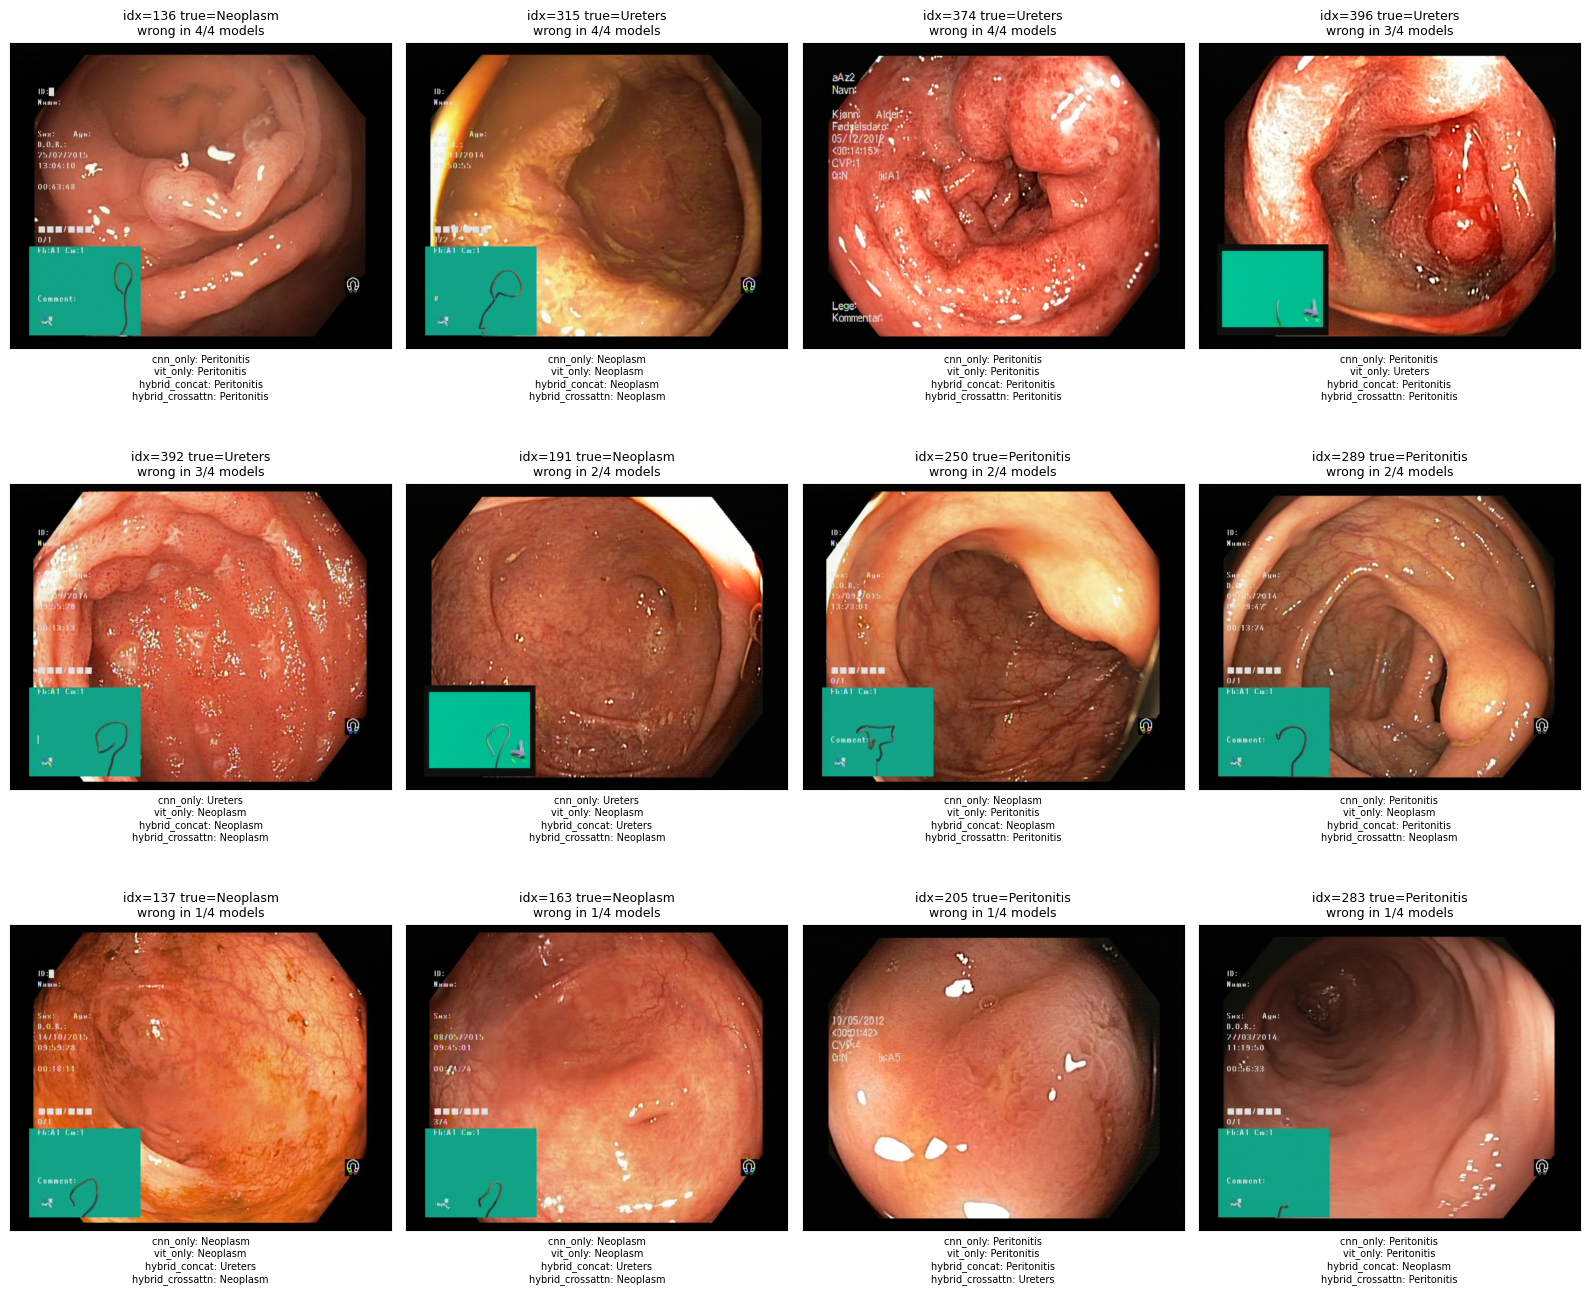

In [9]:
from PIL import Image

TOP_N = min(12, len(error_registry))
top_errors = error_registry.head(TOP_N)

n_cols = 4
n_rows = (TOP_N + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_errors.iterrows()):
    try:
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, f"could not load:\n{e}", ha="center", va="center", wrap=True)
    preds_str = "\n".join(f"{fam.replace('_v2','')}: {row[fam+'_pred']}" for fam in MODEL_FAMILIES)
    ax.set_title(f"idx={row['test_index']} true={row['true_class']}\nwrong in {row['n_models_wrong']}/4 models",
                 fontsize=9)
    ax.set_xlabel(preds_str, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[TOP_N:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Auto-generated interpretation

In [10]:
n_unanimous_wrong = int((n_models_wrong == len(MODEL_FAMILIES)).sum())
n_majority_wrong = int((n_models_wrong >= 3).sum())
top_pair = pair_df.iloc[0] if len(pair_df) else None

print(f"{n_unanimous_wrong} test image(s) are misclassified by ALL 4 architectures -- "
      f"and by definition every model agrees on the (wrong) predicted class too if their "
      f"predictions match; check the table above to confirm.")
print(f"{n_majority_wrong} test image(s) are misclassified by at least 3 of the 4 architectures.")
if top_pair is not None:
    print(f"\nThe single most common confusion across all models: "
          f"true={top_pair['true_class']} predicted-as={top_pair['predicted_as']} "
          f"({top_pair['count_across_all_models']} occurrences pooled across the 4 model families).")

if n_unanimous_wrong > 0:
    print("\n-> Images wrong for every architecture are a real, citable candidate for \"the accuracy "
          "ceiling is partly explained by ambiguous/borderline ground truth\" (A.2/A.3) -- "
          "inspect them manually (Section 7) before writing this claim, but this is exactly "
          "the kind of evidence that supports it rather than pointing at a modeling weakness.")
print("\n-> These specific test_index values (Section 6/7, sorted by n_models_wrong) are what "
      "NB7's Grad-CAM / cross-attention maps should be pointed at first, per the project's own plan.")

3 test image(s) are misclassified by ALL 4 architectures -- and by definition every model agrees on the (wrong) predicted class too if their predictions match; check the table above to confirm.
5 test image(s) are misclassified by at least 3 of the 4 architectures.

The single most common confusion across all models: true=Ureters predicted-as=Peritonitis (10 occurrences pooled across the 4 model families).

-> Images wrong for every architecture are a real, citable candidate for "the accuracy ceiling is partly explained by ambiguous/borderline ground truth" (A.2/A.3) -- inspect them manually (Section 7) before writing this claim, but this is exactly the kind of evidence that supports it rather than pointing at a modeling weakness.

-> These specific test_index values (Section 6/7, sorted by n_models_wrong) are what NB7's Grad-CAM / cross-attention maps should be pointed at first, per the project's own plan.


## 9. Save outputs

Writes the error registry (full list, not just the top-N shown above) and a per-class metrics summary to `EXPERIMENTS_ROOT/analysis/`.

In [11]:
analysis_dir = os.path.join(EXPERIMENTS_ROOT, "analysis")
os.makedirs(analysis_dir, exist_ok=True)

error_registry.to_csv(os.path.join(analysis_dir, "nb6b_error_registry.csv"), index=False)
pair_df.to_csv(os.path.join(analysis_dir, "nb6b_confusion_pairs_pooled.csv"), index=False)

per_class_rows = []
for fam in MODEL_FAMILIES:
    report = classification_report(LABELS, ensembles[fam], target_names=CLASS_NAMES, digits=4, output_dict=True)
    for cls in CLASS_NAMES:
        per_class_rows.append({"model_family": fam, "class": cls, **report[cls]})
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(analysis_dir, "nb6b_per_class_metrics.csv"), index=False)

print(f"Saved 3 CSVs to {analysis_dir}:")
print("  nb6b_error_registry.csv       -- every test image with >=1 model error, all 4 models' predictions")
print("  nb6b_confusion_pairs_pooled.csv -- (true, predicted) pair counts pooled across all 4 models")
print("  nb6b_per_class_metrics.csv    -- precision/recall/F1 per class per model family")

Saved 3 CSVs to /content/drive/MyDrive/gastronet_experiments/analysis:
  nb6b_error_registry.csv       -- every test image with >=1 model error, all 4 models' predictions
  nb6b_confusion_pairs_pooled.csv -- (true, predicted) pair counts pooled across all 4 models
  nb6b_per_class_metrics.csv    -- precision/recall/F1 per class per model family


## Next: NB7

Now that the error registry exists, NB7's Grad-CAM and cross-attention maps (C.2 item 3) should target, in priority order:
1. The `n_models_wrong == 4` images (Section 5/7/8) — check whether they're genuinely ambiguous.
2. The dominant confusion pair from Section 5's pooled table — visualize what evidence each model is (mis)using on those specific images.
3. Any case in the error registry where models *agree on the predicted label* (right or wrong) but might be attending to different regions — the disagreement-in-evidence angle from C.2 item 3, now checkable against real indices instead of guessing which images to pick.